## Load PDF and Split document into chunks

Define Chunk size / Chunk overlap

In [ ]:
# filepath: /home/klismam/workspace/agent_study/rag_app.py
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
# there are many available text splitters:https://docs.langchain.com/oss/python/integrations/splitters
# https://dev.to/eteimz/understanding-langchains-recursivecharactertextsplitter-2846

In [36]:
FILE_NAME = "TWN_Bash_Scripting_Handout.01.pdf"

# Load the PDF document
base_dir = os.getcwd()
loader = PyPDFLoader(os.path.join(base_dir, "documents", FILE_NAME))
documents = loader.load()
# Split the document into smaller chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
splits = text_splitter.split_documents(documents)

In [37]:
documents, len(documents)

([Document(metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 0, 'page_label': '1'}, page_content='Bash Scripting Handout\nby TechWorld with Nana\nAccompanying handout for our tutorial "Bash Scripting" on TWN Youtube channel'),
  Document(metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 1, 'page_label': '2'}, page_content="Table of Contents\n1 Introduction\n2 Understanding Shell, Bash & Terminal\n3 Installation Instructions\n4 Sample Log Files\n5 Basic Linux Commands\n6 Creatin

In [38]:
documents[0].model_dump()

{'id': None,
 'metadata': {'producer': 'GPL Ghostscript 10.00.0',
  'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)',
  'creationdate': "D:20250714130809Z00'00'",
  'moddate': "D:20250714130809Z00'00'",
  'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf',
  'total_pages': 19,
  'page': 0,
  'page_label': '1'},
 'page_content': 'Bash Scripting Handout\nby TechWorld with Nana\nAccompanying handout for our tutorial "Bash Scripting" on TWN Youtube channel',
 'type': 'Document'}

In [39]:
documents[0].page_content[:23]

'Bash Scripting Handout\n'

In [40]:
splits, len(splits)

([Document(metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 0, 'page_label': '1'}, page_content='Bash Scripting Handout\nby TechWorld with Nana\nAccompanying handout for our tutorial "Bash Scripting" on TWN Youtube channel'),
  Document(metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 1, 'page_label': '2'}, page_content="Table of Contents\n1 Introduction\n2 Understanding Shell, Bash & Terminal\n3 Installation Instructions\n4 Sample Log Files\n5 Basic Linux Commands\n6 Creatin

 ## Cerate embeddings and vector store

Embedding models are wrappers around embedding models from different APIs and services.

`SentenceTransformerEmbeddings`: HuggingFace sentence_transformers embedding models. ( https://huggingface.co/sentence-transformers )

---

**Vector store** stores embedded data and performs vector search.

> One of the most common ways to store and search over unstructured data is to
> embed it and store the resulting embedding vectors, and then query the store
> and retrieve the data that are 'most similar' to the embedded query.

**FAISS**: FAISS vector store integration. (https://arxiv.org/pdf/2401.08281)

> Vector databases typically manage large collections of
embedding vectors. As AI applications are growing
rapidly, the number of embeddings that need to be
stored and indexed is increasing. The Faiss library is
dedicated to vector similarity search, a core function
ality of vector databases. Faiss is a toolkit of indexing
methodsandrelatedprimitivesusedtosearch,cluster,
compress and transform vectors. This paper describes
the trade-offs in vector search and the design princi
ples of Faiss in terms of structure, approach to opti
mization and interfacing. We benchmark key features
of the library and discuss a few selected use cases to
highlight its broad applicability


**Embedding text**  
Each sentence is converted into a vector of 384 numbers.  
These vectors represent semantic meaning in a high-dimensional space.  
Sentences with similar meanings will have vectors pointing in similar directions.  

In [49]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
sentences = [ "The weather is lovely today.", "It's so sunny outside!", "He drove to the stadium.", ]
embeddings = model.encode(sentences)

print(embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1856.43it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(3, 384)


Next, we compute pairwise cosine similarity between every vector.

Cosine similarity measures the angle between vectors, not their length.

Formula:

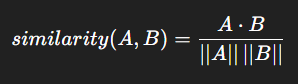


Range:
| Value | Meaning                                        |
| ----- | ---------------------------------------------- |
| 1     | identical meaning                              |
| ~0.7  | strongly related                               |
| ~0.3  | weak relation                                  |
| ~0    | unrelated                                      |
| <0    | opposite meaning (rare in sentence embeddings) |


In [50]:
model.similarity(embeddings, embeddings)

tensor([[1.0000, 0.6660, 0.1046],
        [0.6660, 1.0000, 0.1411],
        [0.1046, 0.1411, 1.0000]])

This is a 3×3 matrix because you have 3 sentences.  

```
        S1     S2     S3
S1    1.00   0.66   0.10
S2    0.66   1.00   0.14
S3    0.10   0.14   1.00
```

Where:

* Rows = sentence A
* Columns = sentence B
* Value = similarity(A,B)

Interpretation:

Sentence 1: "The weather is lovely today."

| Compared with | Similarity | Meaning          |
| ------------- | ---------- | ---------------- |
| Sentence 1    | 1.00       | identical        |
| Sentence 2    | 0.66       | strongly related |
| Sentence 3    | 0.10       | unrelated        |


In [66]:
from langchain_classic.embeddings import SentenceTransformerEmbeddings
from langchain_community.vectorstores import FAISS
# Using langchain's wrapper for sentence transformers and Storing the embeddings in a vector store

model = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(splits, model)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1720.67it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [75]:
# Search for similar documents
vector_store.similarity_search("Nana is a professor that teaches bash scripting")

[Document(id='2d0d70e5-a3a1-4f3c-8ce6-0070025485fc', metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 0, 'page_label': '1'}, page_content='Bash Scripting Handout\nby TechWorld with Nana\nAccompanying handout for our tutorial "Bash Scripting" on TWN Youtube channel'),
 Document(id='d3e4df79-cff4-466f-9b5b-1b291a1ba860', metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 18, 'page_label': '19'}, page_content='benefit from learning shell scripting.\nThis handout accompanies the "B

## Set up the Rag Chain

In [80]:
from langchain_community.llms import Ollama
# Use langchain's wrapper for Ollama
# Dont forget to start your local Ollama server and have the model downloaded and running - see README.md for instructions

llm = Ollama(model="llama3.2")  # Use your local Ollama model

In [81]:
llm.invoke("Good morning")

"Good morning! Hope you're having a great start to the day. How can I assist you today?"

In [107]:
# Create a retriever with a score threshold
retriever = vector_store.as_retriever(kwargs={"search_type": "similarity", "search_kwargs": {"k": 10, "score_threshold": 0.5}})

**Chains** are easily reusable components linked together.

Chains encode a sequence of calls to components like models, document retrievers, other Chains, etc., and provide a simple interface to this sequence.

The Chain interface makes it easy to create apps that are:

    - **Stateful:** add Memory to any Chain to give it state,
    - **Observable:** pass Callbacks to a Chain to execute additional functionality,
        like logging, outside the main sequence of component calls,
    - **Composable:** combine Chains with other components, including other Chains.

In [108]:
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

help(create_retrieval_chain)

Help on function create_retrieval_chain in module langchain_classic.chains.retrieval:

create_retrieval_chain(retriever: 'BaseRetriever | Runnable[dict, RetrieverOutput]', combine_docs_chain: 'Runnable[dict[str, Any], str]') -> 'Runnable'
    Create retrieval chain that retrieves documents and then passes them on.

    Args:
        retriever: Retriever-like object that returns list of documents. Should
            either be a subclass of BaseRetriever or a Runnable that returns
            a list of documents. If a subclass of BaseRetriever, then it
            is expected that an `input` key be passed in - this is what
            is will be used to pass into the retriever. If this is NOT a
            subclass of BaseRetriever, then all the inputs will be passed
            into this runnable, meaning that runnable should take a dictionary
            as input.
        combine_docs_chain: Runnable that takes inputs and produces a string output.
            The inputs to this will be

Prompts can be fetched from the LangSmith hub: https://smith.langchain.com/hub/langchain-ai/retrieval-qa-chat

In [109]:
from langchain_classic import hub

# Fetch the prompt template for retrieval-based question answering
retrieval_qa_chat_prompt = hub.pull("langchain-ai/retrieval-qa-chat")
# This prompt template is designed to guide the language model in generating answers based on retrieved documents, making it suitable for building a retrieval-based question-answering system.
# Combine the llm model and the prompt template into a chain that can process retrieved documents and generate answers 
combine_docs_chain = create_stuff_documents_chain(llm, retrieval_qa_chat_prompt)
# Now, create the full retrieval chain by combining the retriever and the document processing chain
retrieval_chain = create_retrieval_chain(retriever, combine_docs_chain)

In [110]:
retrieval_chain.invoke({"input": "What is bash scripting?"})

{'input': 'What is bash scripting?',
 'context': [Document(id='5bce20d0-3061-40e3-8089-89af1bb7217a', metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 2, 'page_label': '3'}, page_content="Introduction\n/g5DF  What You'll Learn\nUnderstand what shell scripting is and why it's powerful\nSet up a Bash environment on any operating system\nWrite shell scripts that automate repetitive tasks\nUse variables, loops, and conditionals in your scripts\nCreate practical automation scripts for real-world scenarios\n/g7B9  Real-World Impact\nShell scripting can transform tasks that take 30-45 minutes of manual \nwork into automated processes that run in seconds."),
  Document(id='d3e4df79-cff4-466f-9b5b-1b291a1ba860', metadata={'producer': 'GPL 

In [111]:
retrieval_chain.invoke({"input": "Who is the teacher?"})

{'input': 'Who is the teacher?',
 'context': [Document(id='cdaaf00a-92bd-444f-85eb-1da2447d0789', metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 2, 'page_label': '3'}, page_content="This handout will show you exactly how to build that automation.\nWho created this? \nI9m Nana, Co-Founder of TechWorld with Nana.\nAs an engineer and trainer, I'm dedicated to \nhelping engineers build the most valuable and \nhighly-demanded DevOps and Cloud skills.\nThrough my \nYouTube channel and my \ncomprehensive DevOps bootcamps, I've helped \nmillions of engineers master the tools and \nconcepts that drive modern software \ndevelopment.\nHappy learning!\nNana"),
  Document(id='2d0d70e5-a3a1-4f3c-8ce6-0070025485fc', metadata={'producer': 'GPL 

In [116]:
retrieval_chain.invoke({"input": "Which topics are covered in the document?"})

{'input': 'Which topics are covered in the document?',
 'context': [Document(id='fd234d04-fc4c-4ea4-9239-5fb94905b9bd', metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 3, 'page_label': '4'}, page_content="'   Documentation : Scripts serve as living \ndocumentation of processes\n'   Error Reduction : Eliminate human \nmistakes in repetitive tasks"),
  Document(id='43bf31d2-3530-4dd0-9042-c47775b4d920', metadata={'producer': 'GPL Ghostscript 10.00.0', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': "D:20250714130809Z00'00'", 'moddate': "D:20250714130809Z00'00'", 'source': '/home/klismam/workspace/agent_study/documents/TWN_Bash_Scripting_Handout.01.pdf', 'total_pages': 19, 'page': 1, 'page_label': '2'}, pa